# ORU - IPL Analytics Hackaton

Importing required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


/Users/jaspreetkaur/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/8w/70d9nj0n3fg4mz1rrt0dd2780000gn/T/matplotlib-drfr7k0n because there was an issue with the default path (/Users/jaspreetkaur/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


In [ ]:
# Fetch the dataset
Match_Deliveries= pd.read_csv('dataset/deliveries_updated_ipl_upto_2025.csv')

# Match Deliveries Datset

In [3]:
Match_Deliveries.head(3)

,matchId,inning,over_ball,over,ball,batting_team,bowling_team,batsman,non_striker,bowler,batsman_runs,extras,isWide,isNoBall,Byes,LegByes,Penalty,dismissal_kind,player_dismissed,date
0,335982,1,0.1,0,1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,2008-04-18
1,335982,1,0.2,0,2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18
2,335982,1,0.3,0,3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18


In [ ]:
#shape of data - Rows x Columns
Match_Deliveries.shape

(278205, 20)

In [ ]:
Match_Deliveries.dtypes # data types of the records

matchId               int64
inning                int64
over_ball           float64
over                  int64
ball                  int64
batting_team            str
bowling_team            str
batsman                 str
non_striker             str
bowler                  str
batsman_runs          int64
extras                int64
isWide              float64
isNoBall            float64
Byes                float64
LegByes             float64
Penalty             float64
dismissal_kind          str
player_dismissed        str
date                    str
dtype: object

In [ ]:
print(Match_Deliveries.describe) 

<bound method NDFrame.describe of         matchId  inning  over_ball  over  ball           batting_team  \
0        335982       1        0.1     0     1  Kolkata Knight Riders   
1        335982       1        0.2     0     2  Kolkata Knight Riders   
2        335982       1        0.3     0     3  Kolkata Knight Riders   
3        335982       1        0.4     0     4  Kolkata Knight Riders   
4        335982       1        0.5     0     5  Kolkata Knight Riders   
...         ...     ...        ...   ...   ...                    ...   
278200  1473511       2       19.2    19     2           Punjab Kings   
278201  1473511       2       19.3    19     3           Punjab Kings   
278202  1473511       2       19.4    19     4           Punjab Kings   
278203  1473511       2       19.5    19     5           Punjab Kings   
278204  1473511       2       19.6    19     6           Punjab Kings   

                       bowling_team         batsman  non_striker  \
0       Royal Challen

In [ ]:
Match_Deliveries.isna().sum() # checking the null values in the data

matchId                  0
inning                   0
over_ball                0
over                     0
ball                     0
batting_team             0
bowling_team             0
batsman                  0
non_striker              0
bowler                   0
batsman_runs             0
extras                   0
isWide              269125
isNoBall            277042
Byes                277504
LegByes             273990
Penalty             278203
dismissal_kind      264382
player_dismissed    264382
date                     0
dtype: int64

Handling the null values - Imputation

In [8]:
columns_extra = ["isWide", "isNoBall", "Byes", "LegByes", "Penalty"]
Match_Deliveries[columns_extra] = Match_Deliveries[columns_extra].fillna(0)

In [9]:
Match_Deliveries.isna().sum()

matchId                  0
inning                   0
over_ball                0
over                     0
ball                     0
batting_team             0
bowling_team             0
batsman                  0
non_striker              0
bowler                   0
batsman_runs             0
extras                   0
isWide                   0
isNoBall                 0
Byes                     0
LegByes                  0
Penalty                  0
dismissal_kind      264382
player_dismissed    264382
date                     0
dtype: int64

In [ ]:
Match_Deliveries['date']= pd.to_datetime(Match_Deliveries['date']) # convert data record to string

Fetch the Season from the date column

In [11]:
Match_Deliveries['season']=Match_Deliveries['date'].dt.year

In [12]:
# Check duplicate records
Match_Deliveries.duplicated(
    subset=['matchId', 'over', 'ball', 'inning']
).sum()

np.int64(35)

In [13]:
Match_Deliveries = Match_Deliveries.drop_duplicates(
    subset=['matchId', 'inning', 'over', 'ball']
)

In [14]:
Match_Deliveries.shape

(278170, 21)

In [15]:
# Check for Super Over
Match_Deliveries['over'].value_counts()

over
0     14838
1     14680
2     14495
3     14480
4     14468
5     14399
6     14342
7     14327
8     14290
9     14247
10    14170
11    14147
12    14116
13    14001
14    13898
15    13735
16    13505
17    13094
18    12311
19    10627
Name: count, dtype: int64

In [16]:
Match_Deliveries["over_display"] = Match_Deliveries["over"] + 1  

In [17]:
# Check for the Super Over

print(f"Balls with innings: {len(Match_Deliveries[Match_Deliveries['inning'] > 2])}")
print(f"Matches with Super overs: {Match_Deliveries[Match_Deliveries['inning'] > 2]['matchId'].nunique() }")

Balls with innings: 171
Matches with Super overs: 15


In [18]:
print(f" Before Super Overs: {Match_Deliveries.shape}")
# Remove the Super Overs 
Match_Deliveries = Match_Deliveries[Match_Deliveries['inning'] <= 2]

print(f" After removing the Super Overs: {Match_Deliveries.shape}")

 Before Super Overs: (278170, 22)
 After removing the Super Overs: (277999, 22)


Dismissal

In [20]:
# How the batsman got out
Match_Deliveries['dismissal_kind'].value_counts(dropna=False)

dismissal_kind
NaN                      264206
caught                     8654
bowled                     2337
run out                    1144
lbw                         851
caught and bowled           388
stumped                     376
hit wicket                   18
retired hurt                 17
retired out                   5
obstructing the field         3
Name: count, dtype: int64

In [21]:
print("No wicket balls:", Match_Deliveries['dismissal_kind'].isna().sum())
print("Total wickets:", Match_Deliveries['dismissal_kind'].notna().sum())


No wicket balls: 264206
Total wickets: 13793


In [22]:
Match_Deliveries['dismissal_kind'] = Match_Deliveries['dismissal_kind'].fillna('not out')

/var/folders/8w/70d9nj0n3fg4mz1rrt0dd2780000gn/T/ipykernel_1832/1585917006.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


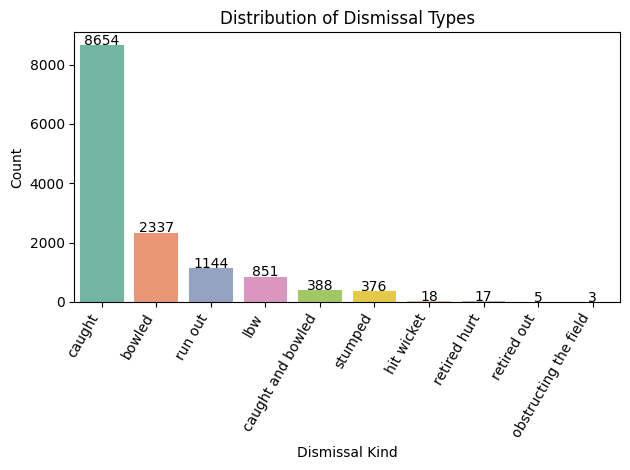

In [23]:
actual_dismissals = Match_Deliveries[
    Match_Deliveries['dismissal_kind'] != 'not out'
]
plt.figure()

ax = sns.countplot(
    data=actual_dismissals,
    x='dismissal_kind',
    order=actual_dismissals['dismissal_kind'].value_counts().index,
    palette='Set2'
)

# Rotate x labels to avoid overlap
plt.xticks(rotation=60, ha='right')

# Add values on top of bars
for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height() + 5,
        int(i.get_height()),
        ha='center'
    )

plt.title('Distribution of Dismissal Types')
plt.xlabel('Dismissal Kind')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Most dismissals are from caught.

Now fetch the unique teams.

In [24]:
print(f"=================Batting Team================={Match_Deliveries['batting_team'].unique()}")
print(f"=================Bowling Team================={Match_Deliveries['bowling_team'].unique()}")

=================Batting Team=================<StringArray>
[      'Kolkata Knight Riders', 'Royal Challengers Bangalore',
         'Chennai Super Kings',             'Kings XI Punjab',
            'Rajasthan Royals',            'Delhi Daredevils',
              'Mumbai Indians',             'Deccan Chargers',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',     'Rising Pune Supergiants',
               'Gujarat Lions',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str
=================Bowling Team=================<StringArray>
['Royal Challengers Bangalore',       'Kolkata Knight Riders',
             'Kings XI Punjab',         'Chennai Super Kings',
            'Delhi Daredevils',            'Rajasthan Royals',
              'Mumbai Indians',             'Deccan Chargers',
      

In [25]:
# Analyse the time span of the teams - First Match year to Last/Current

teams = pd.concat([
    Match_Deliveries[['batting_team', 'season']].rename(columns={'batting_team': 'team'}),
    Match_Deliveries[['bowling_team', 'season']].rename(columns={'bowling_team': 'team'})
])

In [26]:
team_period = teams.groupby('team')['season'].agg(['min', 'max']).reset_index()

team_period = team_period.rename(columns={
    'min': 'first_season',
    'max': 'last_season'
})
team_period = team_period.sort_values('first_season')

team_period

,team,first_season,last_season
0,Chennai Super Kings,2008,2025
1,Deccan Chargers,2008,2012
16,Royal Challengers Bangalore,2008,2023
3,Delhi Daredevils,2008,2018
13,Rajasthan Royals,2008,2025
6,Kings XI Punjab,2008,2020
8,Kolkata Knight Riders,2008,2025
10,Mumbai Indians,2008,2025
11,Pune Warriors,2011,2013
7,Kochi Tuskers Kerala,2011,2011


In [ ]:
 #Map the team names for consistency

team_map = {
    'Kings XI Punjab': 'Punjab Kings', # In 2021
    'Delhi Daredevils': 'Delhi Capitals', # In 2019
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru', # In 2024
    ''
}

Match_Deliveries['batting_team'] = Match_Deliveries['batting_team'].replace(team_map)
Match_Deliveries['bowling_team'] = Match_Deliveries['bowling_team'].replace(team_map)

In [28]:
Match_Deliveries.isnull().sum()

matchId                  0
inning                   0
over_ball                0
over                     0
ball                     0
batting_team             0
bowling_team             0
batsman                  0
non_striker              0
bowler                   0
batsman_runs             0
extras                   0
isWide                   0
isNoBall                 0
Byes                     0
LegByes                  0
Penalty                  0
dismissal_kind           0
player_dismissed    264206
date                     0
season                   0
over_display             0
dtype: int64

In [29]:
Match_Deliveries['player_dismissed']= Match_Deliveries['player_dismissed'].fillna(0)

In [30]:
Match_Deliveries.isnull().sum()

matchId             0
inning              0
over_ball           0
over                0
ball                0
batting_team        0
bowling_team        0
batsman             0
non_striker         0
bowler              0
batsman_runs        0
extras              0
isWide              0
isNoBall            0
Byes                0
LegByes             0
Penalty             0
dismissal_kind      0
player_dismissed    0
date                0
season              0
over_display        0
dtype: int64

In [31]:
Match_Deliveries['total_runs'] = Match_Deliveries['batsman_runs'] + Match_Deliveries['extras']

In [32]:
Match_Deliveries['valid_ball']= ((Match_Deliveries['isWide']== 0 ) 
                                 & (Match_Deliveries['isNoBall'] == 0).astype(int))

In [33]:
print(f" Wide Balls: {Match_Deliveries.isWide.sum()}")
print(f" No Ball: {Match_Deliveries.isNoBall.sum()}")
print(f" Valid Balls: {Match_Deliveries.valid_ball.sum()}")

 Wide Balls: 10878.0
 No Ball: 1193.0
 Valid Balls: 267767


In [34]:
# Univariate Analysis

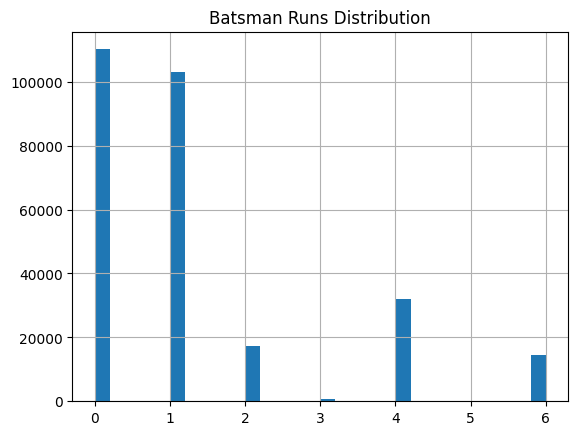

In [35]:
# Runs distribution
plt.figure()
Match_Deliveries["batsman_runs"].hist(bins=30)
plt.title("Batsman Runs Distribution")
plt.show()

/opt/homebrew/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7132: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


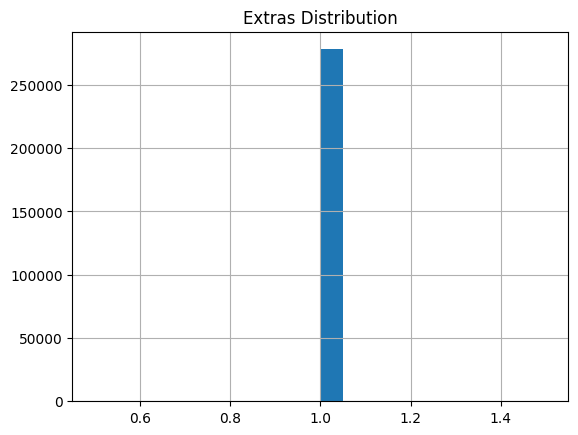

In [36]:
# Extras distribution
plt.figure()
Match_Deliveries["extras"].notna().hist(bins=20)
plt.title("Extras Distribution")
plt.show()

In [37]:
# Top batsmen
top_batsmen = Match_Deliveries.groupby("batsman")["batsman_runs"].sum().sort_values(ascending=False).head(10)
print("\nTop Batsmen:\n", top_batsmen)


Top Batsmen:
 batsman
V Kohli           8661
RG Sharma         7046
S Dhawan          6769
DA Warner         6565
SK Raina          5528
MS Dhoni          5439
KL Rahul          5222
AB de Villiers    5162
AM Rahane         5030
CH Gayle          4965
Name: batsman_runs, dtype: int64


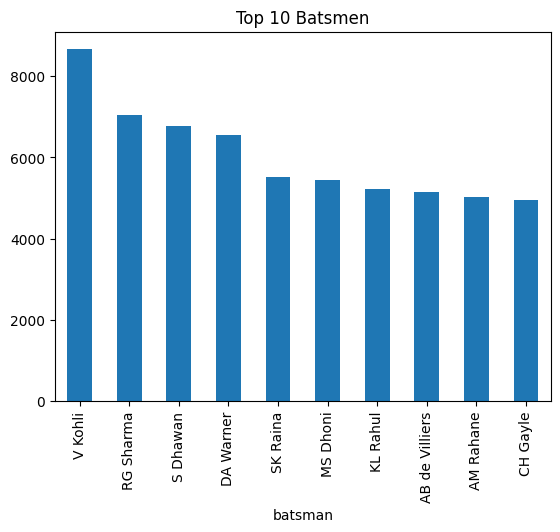

In [38]:
# Plot top batsmen
plt.figure()
top_batsmen.plot(kind="bar")
plt.title("Top 10 Batsmen")
plt.show()

In [39]:
top_bowlers = (
    Match_Deliveries[Match_Deliveries["dismissal_kind"].notna()]
    .groupby("bowler")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop Bowlers:\n", top_bowlers)


Top Bowlers:
 bowler
R Ashwin           4868
SP Narine          4415
B Kumar            4376
RA Jadeja          4127
YS Chahal          3905
PP Chawla          3895
Harbhajan Singh    3496
JJ Bumrah          3449
A Mishra           3444
AR Patel           3365
dtype: int64


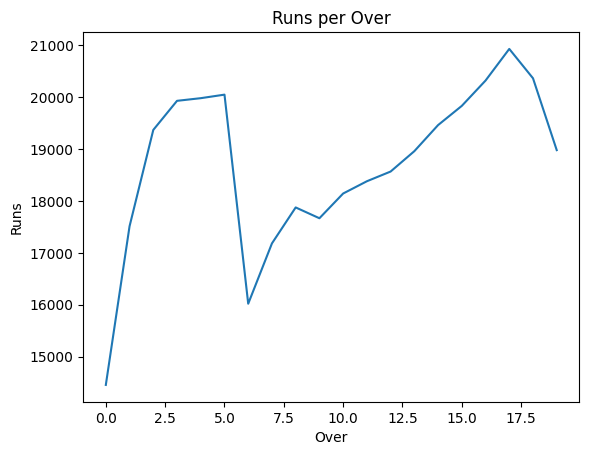

In [40]:
# Over Wise

over_runs = Match_Deliveries.groupby("over")["total_runs"].sum()

plt.figure()
over_runs.plot()
plt.title("Runs per Over")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.show()


Team Scores:
 batting_team
Mumbai Indians                 45037
Royal Challengers Bengaluru    43227
Punjab Kings                   42807
Delhi Capitals                 41650
Kolkata Knight Riders          41289
Chennai Super Kings            41057
Rajasthan Royals               37310
Sunrisers Hyderabad            31552
Deccan Chargers                11459
Gujarat Titans                 10644
Lucknow Super Giants           10235
Pune Warriors                   6358
Gujarat Lions                   4856
Rising Pune Supergiant          2470
Rising Pune Supergiants         2063
Kochi Tuskers Kerala            1901
Name: total_runs, dtype: int64


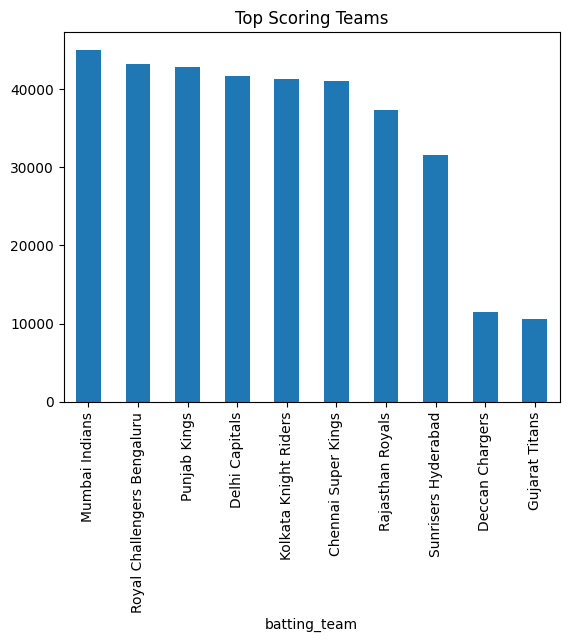

In [ ]:


team_scores = Match_Deliveries.groupby("batting_team")["total_runs"].sum().sort_values(ascending=False)

print("\nTeam Scores:\n", team_scores)

plt.figure()
team_scores.head(10).plot(kind="bar")
plt.title("Top Scoring Teams")
plt.show()

In [43]:
print("\nInsights Summary:")
print("- Total Matches:", Match_Deliveries["matchId"].nunique())
print("- Total Runs:", Match_Deliveries["total_runs"].sum())
total_wickets = Match_Deliveries[
    Match_Deliveries["dismissal_kind"].notna() &
    (Match_Deliveries["dismissal_kind"] != "Not Out") &
    (Match_Deliveries["dismissal_kind"] != "")
].shape[0]
print("- Total Wickets:", total_wickets)
print("- Total Deliveries:", len(Match_Deliveries))


Insights Summary:
- Total Matches: 1169
- Total Runs: 373915
- Total Wickets: 277999
- Total Deliveries: 277999


In [44]:
print(Match_Deliveries["dismissal_kind"].value_counts())

dismissal_kind
not out                  264206
caught                     8654
bowled                     2337
run out                    1144
lbw                         851
caught and bowled           388
stumped                     376
hit wicket                   18
retired hurt                 17
retired out                   5
obstructing the field         3
Name: count, dtype: int64


In [45]:
Match_Deliveries["player_dismissed"].value_counts()

player_dismissed
0                  264206
RG Sharma             237
V Kohli               219
S Dhawan              193
KD Karthik            184
                    ...  
M Tiwari                1
Sediqullah Atal         1
MP Breetzke             1
Musheer Khan            1
BKG Mendis              1
Name: count, Length: 657, dtype: int64

In [46]:
total_wickets = Match_Deliveries["player_dismissed"].notna().sum()

In [47]:
print(total_wickets)

277999


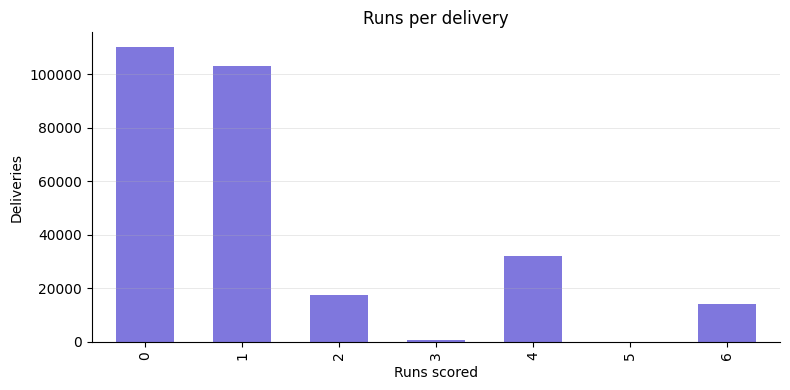

In [48]:
runs = Match_Deliveries['batsman_runs'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
runs.plot(kind='bar', ax=ax, color='#7F77DD', edgecolor='none', width=0.6)
ax.set_xlabel('Runs scored')
ax.set_ylabel('Deliveries')
ax.set_title('Runs per delivery')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', linewidth=0.4, alpha=0.5)
plt.tight_layout(); plt.show()

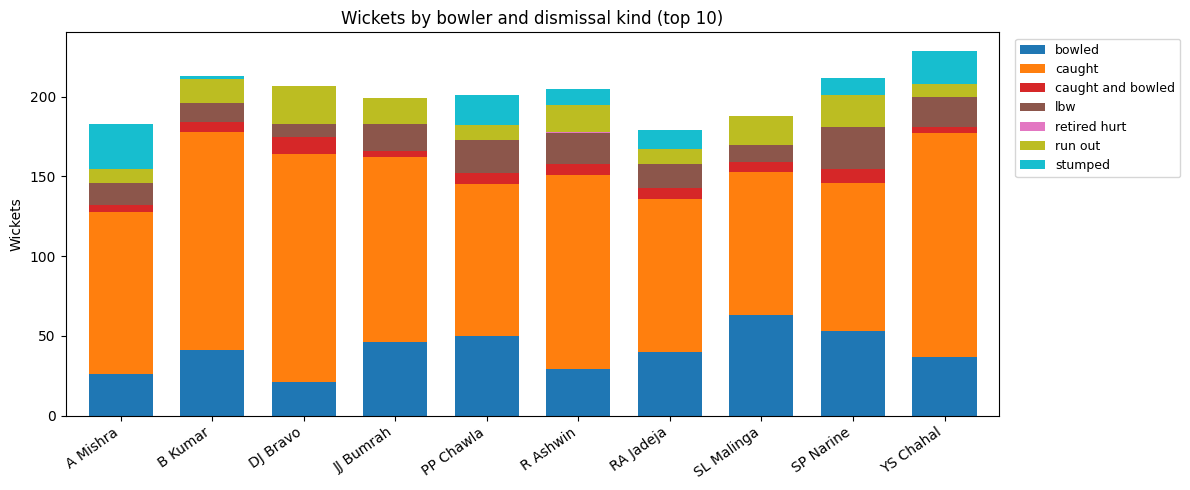

In [49]:
wickets = Match_Deliveries[Match_Deliveries['dismissal_kind'] != "not out"]

top_bowlers = wickets['bowler'].value_counts().head(10).index
wdf = wickets[wickets['bowler'].isin(top_bowlers)]

pivot = wdf.groupby(['bowler','dismissal_kind']).size().unstack(fill_value=0)

pivot.plot(kind='bar', stacked=True, figsize=(12, 5),
           colormap='tab10', edgecolor='none', width=0.7)
plt.title('Wickets by bowler and dismissal kind (top 10)')
plt.ylabel('Wickets')
plt.xlabel('')
plt.xticks(rotation=35, ha='right')
plt.legend(bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout(); plt.show()

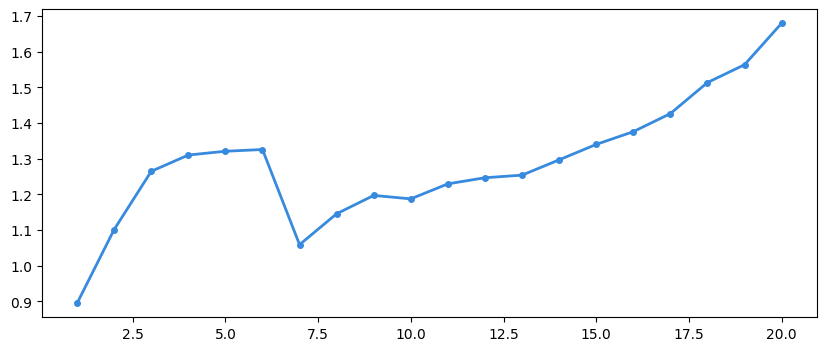

In [50]:
# Runs per Over

over_runs = Match_Deliveries.groupby('over')['batsman_runs'].mean().reset_index()

over_runs['over_display'] = over_runs['over'] + 1  # add this line

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(over_runs['over_display'], over_runs['batsman_runs'],
        color='#378ADD', linewidth=2, marker='o', markersize=4)

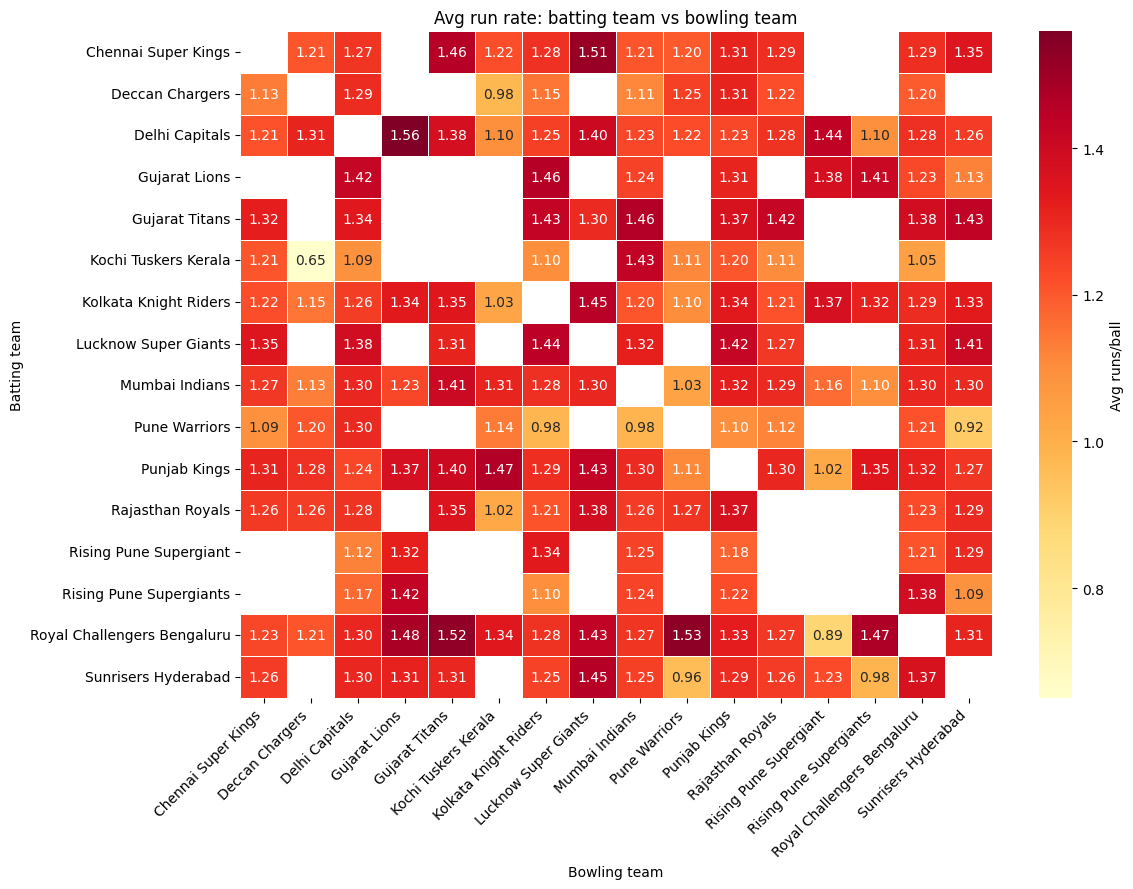

In [51]:
rr = Match_Deliveries.groupby(['batting_team','bowling_team'])['batsman_runs'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(rr, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.4, linecolor='white', ax=ax,
            cbar_kws={'label': 'Avg runs/ball'})
ax.set_title('Avg run rate: batting team vs bowling team')
ax.set_xlabel('Bowling team')
ax.set_ylabel('Batting team')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

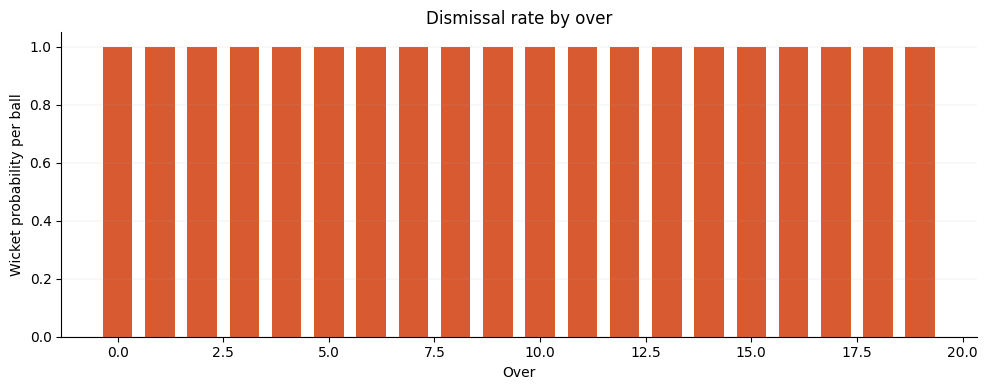

In [52]:
Match_Deliveries['is_wicket'] = Match_Deliveries['dismissal_kind'].notna().astype(int)

wkt_rate = Match_Deliveries.groupby('over')['is_wicket'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(wkt_rate['over'], wkt_rate['is_wicket'],
       color='#D85A30', edgecolor='none', width=0.7)
ax.set_xlabel('Over')
ax.set_ylabel('Wicket probability per ball')
ax.set_title('Dismissal rate by over')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', linewidth=0.3, alpha=0.4)
plt.tight_layout(); plt.show()

# Matches Dataset

In [ ]:
import pandas as pd

In [53]:
Matches= pd.read_csv('dataset/matches_updated_ipl_upto_2025.csv')

In [54]:
Matches.head(3)

,season,venue,event,winner_runs,umpire2,toss_winner,date,neutralvenue,umpire1,city,...,team2,balls_per_over,winner_wickets,tv_umpire,player_of_match,match_referee,outcome,date2,match_number,matchId
0,2007/08,M Chinnaswamy Stadium,Indian Premier League,140.0,RE Koertzen,Royal Challengers Bangalore,2008-04-18,NaN,Asad Rauf,Bangalore,...,Kolkata Knight Riders,6,NaN,AM Saheba,BB McCullum,J Srinath,NaN,NaN,1.0,335982
1,2007/08,"Punjab Cricket Association Stadium, Mohali",Indian Premier League,33.0,SL Shastri,Chennai Super Kings,2008-04-19,NaN,MR Benson,Chandigarh,...,Chennai Super Kings,6,NaN,RB Tiffin,MEK Hussey,S Venkataraghavan,NaN,NaN,2.0,335983
2,2007/08,Feroz Shah Kotla,Indian Premier League,NaN,GA Pratapkumar,Rajasthan Royals,2008-04-19,NaN,Aleem Dar,Delhi,...,Rajasthan Royals,6,9.0,IL Howell,MF Maharoof,GR Viswanath,NaN,NaN,3.0,335984


In [55]:
Matches.describe()

,winner_runs,balls_per_over,winner_wickets,match_number,matchId
count,531.000000,1169.0,615.000000,1099.000000,1.169000e+03
mean,30.295669,6.0,6.200000,31.693358,9.408352e+05
std,26.866707,0.0,1.852193,18.497321,3.819244e+05
min,1.000000,6.0,1.000000,1.000000,3.359820e+05
25%,11.000000,6.0,5.000000,16.000000,5.483520e+05
50%,22.000000,6.0,6.000000,31.000000,1.082598e+06
75%,41.000000,6.0,7.500000,47.000000,1.304047e+06
max,146.000000,6.0,10.000000,72.000000,1.485779e+06


In [ ]:
Matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season           1169 non-null   str    
 1   venue            1169 non-null   str    
 2   event            1169 non-null   str    
 3   winner_runs      531 non-null    float64
 4   umpire2          1169 non-null   str    
 5   toss_winner      1169 non-null   str    
 6   date             1169 non-null   str    
 7   neutralvenue     77 non-null     object 
 8   umpire1          1169 non-null   str    
 9   city             1118 non-null   str    
 10  reserve_umpire   1145 non-null   str    
 11  winner           1146 non-null   str    
 12  eliminator       15 non-null     str    
 13  date1            2 non-null      str    
 14  method           19 non-null     str    
 15  team1            1169 non-null   str    
 16  toss_decision    1169 non-null   str    
 17  gender           1169 non

In [56]:
Matches.isnull().sum()

season                0
venue                 0
event                 0
winner_runs         638
umpire2               0
toss_winner           0
date                  0
neutralvenue       1092
umpire1               0
city                 51
reserve_umpire       24
winner               23
eliminator         1154
date1              1167
method             1150
team1                 0
toss_decision         0
gender                0
team2                 0
balls_per_over        0
winner_wickets      554
tv_umpire             4
player_of_match       8
match_referee         0
outcome            1146
date2              1167
match_number         70
matchId               0
dtype: int64

In [57]:
Matches.shape

(1169, 28)

In [58]:
#Winner Runs

Matches['winner_runs'].value_counts()

winner_runs
10.0     18
14.0     17
12.0     16
4.0      16
18.0     15
         ..
112.0     1
106.0     1
100.0     1
83.0      1
110.0     1
Name: count, Length: 101, dtype: int64

In [59]:
run_wins= Matches['winner_runs'].notnull().sum()
wicket_wins= Matches['winner_wickets'].notnull().sum()

total_wins= run_wins+ wicket_wins

print(f"Matches won by Runs:{run_wins}")
print(f"Matches won by Wickets:{wicket_wins}")


print(f"Run Wins: {(run_wins/total_wins)*100:.2f}% | Wicket Wins: {(wicket_wins/total_wins)*100:.2f}% ")

Matches won by Runs:531
Matches won by Wickets:615
Run Wins: 46.34% | Wicket Wins: 53.66% 


More matches won by wickets. Teams chasing ( batting 2nd) win more often. Chasing advantage.

In [60]:
print(f"Avg Run Margin: {Matches['winner_runs'].mean():.2f} runs")

print(f"Avg Wicket Margin: {Matches['winner_wickets'].mean():.2f} wickets")

Avg Run Margin: 30.30 runs
Avg Wicket Margin: 6.20 wickets


Defending teams wins by about 30 runs on average, while teams chasing win by about 6 wickets.Both wins are comfortable rather than close finishes.

In [61]:
Matches['winner_runs'] = Matches['winner_runs'].fillna(0)
    

In [62]:
Matches['winner_wickets'] = Matches['winner_wickets'].fillna(0)

In [64]:
Matches['neutralvenue'].value_counts(dropna=False)

neutralvenue
NaN     1092
True      77
Name: count, dtype: int64

In [65]:
Matches['city'].value_counts(dropna=False)

city
Mumbai            180
Kolkata           100
Delhi              97
Chennai            91
Hyderabad          83
Bangalore          65
Jaipur             64
Chandigarh         61
Pune               51
NaN                51
Ahmedabad          45
Abu Dhabi          37
Bengaluru          34
Lucknow            22
Visakhapatnam      17
Durban             15
Dharamsala         15
Dubai              13
Centurion          12
Rajkot             10
Sharjah            10
Indore              9
Navi Mumbai         9
Mohali              9
Johannesburg        8
Cape Town           7
Port Elizabeth      7
Cuttack             7
Ranchi              7
Raipur              6
Kochi               5
Guwahati            5
Kanpur              4
East London         3
Kimberley           3
Nagpur              3
Bloemfontein        2
New Chandigarh      2
Name: count, dtype: int64

Check the venues where the cities are null.

In [69]:
Matches['city'].value_counts(dropna=False)

city
Mumbai            180
Kolkata           100
Delhi              97
Chennai            91
Hyderabad          83
Bangalore          65
Jaipur             64
Chandigarh         61
Pune               51
NaN                51
Ahmedabad          45
Abu Dhabi          37
Bengaluru          34
Lucknow            22
Visakhapatnam      17
Durban             15
Dharamsala         15
Dubai              13
Centurion          12
Rajkot             10
Sharjah            10
Indore              9
Navi Mumbai         9
Mohali              9
Johannesburg        8
Cape Town           7
Port Elizabeth      7
Cuttack             7
Ranchi              7
Raipur              6
Kochi               5
Guwahati            5
Kanpur              4
East London         3
Kimberley           3
Nagpur              3
Bloemfontein        2
New Chandigarh      2
Name: count, dtype: int64

In [73]:
Matches[Matches['city'].isnull()]['venue'].unique()

<StringArray>
['Sharjah Cricket Stadium', 'Dubai International Cricket Stadium']
Length: 2, dtype: str

Missing cities are for only these Venues, fetching the cities.

In [74]:
city_venue_map = {
    'Sharjah Cricket Stadium': 'Sharjah',
    'Dubai International Cricket Stadium': 'Dubai'
}

Matches['city'] = Matches['city'].fillna(Matches['venue'].map(city_venue_map))

In [79]:
Matches['neutralvenue'] = Matches['neutralvenue'].fillna(False)

In [80]:
Matches['neutralvenue'] = Matches['neutralvenue'].astype(bool)

In [81]:
Matches['eliminator'].value_counts(dropna=False)

eliminator
NaN                            1154
Delhi Capitals                    4
Kings XI Punjab                   3
Rajasthan Royals                  2
Royal Challengers Bangalore       2
Mumbai Indians                    2
Sunrisers Hyderabad               1
Kolkata Knight Riders             1
Name: count, dtype: int64

In [82]:
Matches['eliminator'] = Matches['eliminator'].fillna('Not Eliminator Match')

In [83]:
Matches['method'].value_counts(dropna=False)

method
NaN    1150
D/L      19
Name: count, dtype: int64

Match result decided when the game was effected by the weather. D/L = Duckworth–Lewis. Used in limited overs cricket to adjust scores.

In [87]:
Matches['method']= Matches['method'].fillna('Normal')



In [89]:
Matches.isnull().sum()

season                0
venue                 0
event                 0
winner_runs           0
umpire2               0
toss_winner           0
date                  0
neutralvenue          0
umpire1               0
city                  0
reserve_umpire       24
winner               23
eliminator            0
date1              1167
method                0
team1                 0
toss_decision         0
gender                0
team2                 0
balls_per_over        0
winner_wickets        0
tv_umpire             4
player_of_match       8
match_referee         0
outcome            1146
date2              1167
match_number         70
matchId               0
dtype: int64

In [90]:
Matches['outcome'].value_counts(dropna=False)

outcome
NaN          1146
tie            15
no result       8
Name: count, dtype: int64

In [91]:
Matches['outcome'] = Matches['outcome'].fillna('normal')

In [92]:
Matches.isnull().sum()

season                0
venue                 0
event                 0
winner_runs           0
umpire2               0
toss_winner           0
date                  0
neutralvenue          0
umpire1               0
city                  0
reserve_umpire       24
winner               23
eliminator            0
date1              1167
method                0
team1                 0
toss_decision         0
gender                0
team2                 0
balls_per_over        0
winner_wickets        0
tv_umpire             4
player_of_match       8
match_referee         0
outcome               0
date2              1167
match_number         70
matchId               0
dtype: int64

In [93]:
Matches['date1'].value_counts(dropna=False)

date1
NaN           1167
2014/05/27       1
2017/05/17       1
Name: count, dtype: int64

In [94]:
Matches['date2'].value_counts(dropna=False)

date2
NaN           1167
2014/05/28       1
2017/05/18       1
Name: count, dtype: int64

In [96]:
Matches['date'].isnull().sum()

np.int64(0)

Dropping the redundant columns

In [97]:
Matches.drop(columns=['date1', 'date2'], inplace=True)

In [98]:
Matches.isnull().sum()

season              0
venue               0
event               0
winner_runs         0
umpire2             0
toss_winner         0
date                0
neutralvenue        0
umpire1             0
city                0
reserve_umpire     24
winner             23
eliminator          0
method              0
team1               0
toss_decision       0
gender              0
team2               0
balls_per_over      0
winner_wickets      0
tv_umpire           4
player_of_match     8
match_referee       0
outcome             0
match_number       70
matchId             0
dtype: int64

Analysing the matches where no winner. Either there is tie or there is no result of the match

In [99]:
Matches[Matches['winner'].isnull()][['team1','team2','outcome']]

,team1,team2,outcome
65,Kolkata Knight Riders,Rajasthan Royals,tie
129,Chennai Super Kings,Kings XI Punjab,tie
241,Delhi Daredevils,Pune Warriors,no result
328,Sunrisers Hyderabad,Royal Challengers Bangalore,tie
342,Royal Challengers Bangalore,Delhi Daredevils,tie
416,Kolkata Knight Riders,Rajasthan Royals,tie
475,Rajasthan Royals,Kings XI Punjab,tie
485,Royal Challengers Bangalore,Rajasthan Royals,no result
511,Royal Challengers Bangalore,Delhi Daredevils,no result
609,Gujarat Lions,Mumbai Indians,tie


In [103]:
Matches['winner']= Matches['winner'].fillna('No Result')

In [104]:
Matches.isnull().sum()

season              0
venue               0
event               0
winner_runs         0
umpire2             0
toss_winner         0
date                0
neutralvenue        0
umpire1             0
city                0
reserve_umpire     24
winner              0
eliminator          0
method              0
team1               0
toss_decision       0
gender              0
team2               0
balls_per_over      0
winner_wickets      0
tv_umpire           4
player_of_match     8
match_referee       0
outcome             0
match_number       70
matchId             0
dtype: int64

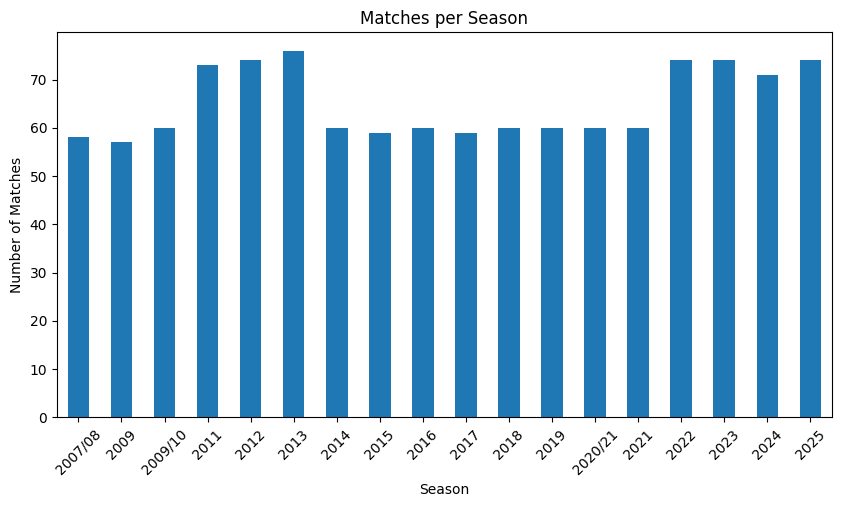

In [106]:
matches_per_season = Matches['season'].value_counts().sort_index()

matches_per_season.plot(kind='bar', figsize=(10,5))

plt.title("Matches per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.show()

In [107]:
Matches['season'].unique()

<StringArray>
['2007/08',    '2009', '2009/10',    '2011',    '2012',    '2013',    '2014',
    '2015',    '2016',    '2017',    '2018',    '2019', '2020/21',    '2021',
    '2022',    '2023',    '2024',    '2025']
Length: 18, dtype: str

Handle the season.

In [108]:
Matches['season'] = Matches['season'].astype(str).str.extract(r'(\d{4})').astype(int)

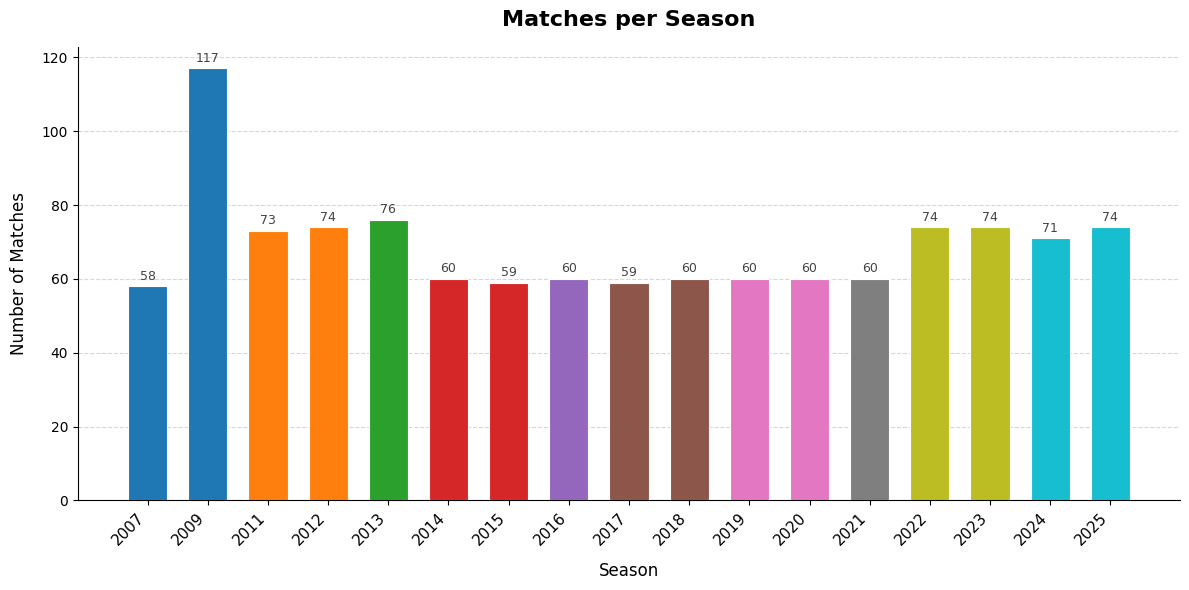

In [111]:
import numpy as np 

matches_per_season = Matches['season'].value_counts().sort_index()

colors = plt.cm.tab10(np.linspace(0, 1, len(matches_per_season)))

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    range(len(matches_per_season)),
    matches_per_season.values,
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.65
)

ax.set_xticks(range(len(matches_per_season)))
ax.set_xticklabels(matches_per_season.index, rotation=45, ha='right', fontsize=11)
ax.set_title("Matches per Season", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Season", fontsize=12, labelpad=10)
ax.set_ylabel("Number of Matches", fontsize=12, labelpad=10)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=9, color='#444'
    )

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Mapping the Teams

In [ ]:
team_map = {
    'Kings XI Punjab': 'Punjab Kings', # In 2021
    'Delhi Daredevils': 'Delhi Capitals', # In 2019
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru', # In 2024
    'Rising Pune Supergiants': 'Rising Pune Supergiant' # In 2017
}

for column in ['team1', 'team2', 'toss_winner', 'winner']:
    Matches[column] = Matches[column].replace(team_map)

In [113]:
Matches.duplicated().sum()

np.int64(0)

Toss influence on the matches

In [ ]:
toss_win_match_win = (Matches['toss_winner'] == Matches['winner']).sum()
total_matches = Matches.shape[0]

print("Toss winner also won match:", toss_win_match_win)
print("Total matches:", total_matches)
print("Toss win influence %:", (toss_win_match_win / total_matches) * 100:,2f)

Toss winner also won match: 591
Total matches: 1169
Toss win influence %: 50.556030795551756


In [122]:
Matches['toss_win'] = Matches['toss_winner'] == Matches['winner']

summary = Matches.groupby('toss_decision')['toss_win'].agg(['count','mean'])
summary['percentage'] = summary['mean'] * 100

print(summary)

               count      mean  percentage
toss_decision                             
bat              405  0.451852   45.185185
field            764  0.534031   53.403141


In [135]:
total = len(Matches.dropna(subset=['winner']))

toss_wins = (Matches['toss_winner'] == Matches['winner']).sum()

win_by_runs    = Matches[Matches['winner_runs'] > 0]['winner_runs'].count()
win_by_wickets = Matches[Matches['winner_wickets'] > 0]['winner_wickets'].count()
missing        = total - win_by_runs - win_by_wickets

print("=" * 45)
print("      TOSS & MATCH ANALYSIS SUMMARY")
print("=" * 45)
print(f"  Total matches played       : {total}")
print(f"  Toss winner won match      : {int(toss_wins)} ({toss_wins/total*100:.1f}%)")
print(f"  Toss winner lost match     : {int(total-toss_wins)} ({(total-toss_wins)/total*100:.1f}%)")
print("-" * 45)
print(f"  Won by Runs                : {win_by_runs} ({win_by_runs/total*100:.1f}%)")
print(f"  Won by Wickets             : {win_by_wickets} ({win_by_wickets/total*100:.1f}%)")
print(f"  No Result                  : {missing} ({missing/total*100:.1f}%)")
print("=" * 45)

      TOSS & MATCH ANALYSIS SUMMARY
  Total matches played       : 1169
  Toss winner won match      : 591 (50.6%)
  Toss winner lost match     : 578 (49.4%)
---------------------------------------------
  Won by Runs                : 531 (45.4%)
  Won by Wickets             : 615 (52.6%)
  No Result                  : 23 (2.0%)


/var/folders/8w/70d9nj0n3fg4mz1rrt0dd2780000gn/T/ipykernel_1832/2183499157.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(seasons, rotation=45, ha='right', fontsize=10)


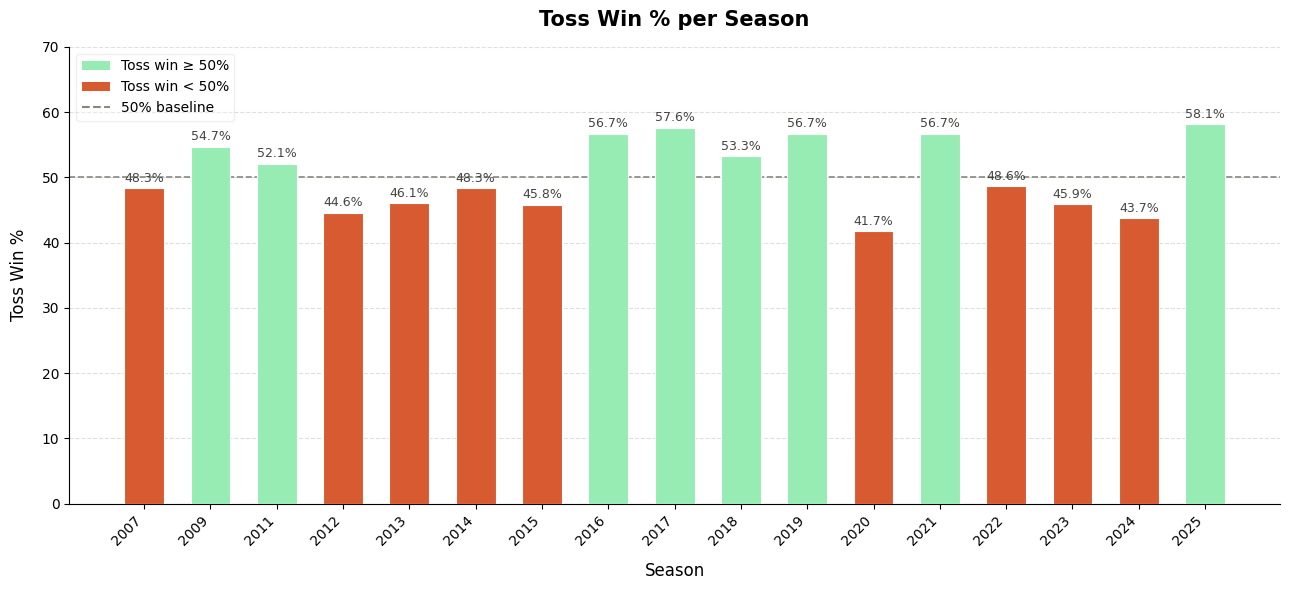

In [138]:

toss_per_season = Matches.groupby('season').apply(
    lambda x: pd.Series({
        'total_matches': len(x),
        'toss_wins': (x['toss_winner'] == x['winner']).sum(),
    })
).reset_index()

toss_per_season['win_pct'] = (toss_per_season['toss_wins'] / toss_per_season['total_matches'] * 100).round(1)

seasons = toss_per_season['season'].astype(str)
win_pct = toss_per_season['win_pct']

colors = ['#96ECB2' if p >= 50 else '#D85A30' for p in win_pct]

fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(seasons, win_pct, color=colors, edgecolor='white', linewidth=0.8, width=0.6, zorder=3)

# 50% reference line
ax.axhline(50, color='#888780', linestyle='--', linewidth=1.2, zorder=2, label='50% baseline')

# value labels on bars
for bar, val in zip(bars, win_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val}%',
        ha='center', va='bottom', fontsize=9, color='#444441'
    )

ax.set_title('Toss Win % per Season', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Season', fontsize=12, labelpad=10)
ax.set_ylabel('Toss Win %', fontsize=12, labelpad=10)
ax.set_ylim(0, 70)
ax.set_xticklabels(seasons, rotation=45, ha='right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#96ECB2", label='Toss win ≥ 50%'),
    Patch(facecolor='#D85A30', label='Toss win < 50%'),
    plt.Line2D([0], [0], color='#888780', linestyle='--', label='50% baseline')
]
ax.legend(handles=legend_elements, fontsize=10, framealpha=0.3)

plt.tight_layout()
plt.show()

In [139]:
Matches.isna().sum()

season              0
venue               0
event               0
winner_runs         0
umpire2             0
toss_winner         0
date                0
neutralvenue        0
umpire1             0
city                0
reserve_umpire     24
winner              0
eliminator          0
method              0
team1               0
toss_decision       0
gender              0
team2               0
balls_per_over      0
winner_wickets      0
tv_umpire           4
player_of_match     8
match_referee       0
outcome             0
match_number       70
matchId             0
toss_win            0
dtype: int64

In [ ]:
Matches.rename(columns={'matchId': 'match_id'}, inplace=True) 


In [ ]:
Match_Deliveries.rename(columns={'matchId': 'match_id'}, inplace=True) 

# Merfing the datasets Deleivers data ball by ball with the Matches

In [142]:
IPL_Dataset= Match_Deliveries.merge(Matches, on='match_id', how='left')

In [144]:
IPL_Dataset.shape

(277999, 51)

In [150]:
IPL_Dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 277999 entries, 0 to 277998
Data columns (total 51 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   match_id          277999 non-null  int64         
 1   inning            277999 non-null  int64         
 2   over_ball         277999 non-null  float64       
 3   over              277999 non-null  int64         
 4   ball              277999 non-null  int64         
 5   batting_team      277999 non-null  str           
 6   bowling_team      277999 non-null  str           
 7   batsman           277999 non-null  str           
 8   non_striker       277999 non-null  str           
 9   bowler            277999 non-null  str           
 10  batsman_runs      277999 non-null  int64         
 11  extras            277999 non-null  int64         
 12  isWide            277999 non-null  float64       
 13  isNoBall          277999 non-null  float64       
 14  Byes           

In [153]:
IPL_Dataset.head(2)

,match_id,inning,over_ball,over,ball,batting_team,bowling_team,batsman,non_striker,bowler,...,gender,team2,balls_per_over,winner_wickets,tv_umpire,player_of_match,match_referee,outcome,match_number,toss_win
0,335982,1,0.1,0,1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,P Kumar,...,male,Kolkata Knight Riders,6,0.0,AM Saheba,BB McCullum,J Srinath,normal,1.0,False
1,335982,1,0.2,0,2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,...,male,Kolkata Knight Riders,6,0.0,AM Saheba,BB McCullum,J Srinath,normal,1.0,False


In [156]:
print(IPL_Dataset.columns.tolist())


['match_id', 'inning', 'over_ball', 'over', 'ball', 'batting_team', 'bowling_team', 'batsman', 'non_striker', 'bowler', 'batsman_runs', 'extras', 'isWide', 'isNoBall', 'Byes', 'LegByes', 'Penalty', 'dismissal_kind', 'player_dismissed', 'date_x', 'season_x', 'over_display', 'total_runs', 'valid_ball', 'is_wicket', 'season_y', 'venue', 'event', 'winner_runs', 'umpire2', 'toss_winner', 'date_y', 'neutralvenue', 'umpire1', 'city', 'reserve_umpire', 'winner', 'eliminator', 'method', 'team1', 'toss_decision', 'gender', 'team2', 'balls_per_over', 'winner_wickets', 'tv_umpire', 'player_of_match', 'match_referee', 'outcome', 'match_number', 'toss_win']


In [159]:
print("date match:")
print((IPL_Dataset['date_x'] == IPL_Dataset['date_y']).value_counts())

print("\nseason match:")
print((IPL_Dataset['season_x'] == IPL_Dataset['season_y']).value_counts())

date match:
True    277999
Name: count, dtype: int64

season match:
True     250025
False     27974
Name: count, dtype: int64


Observed duplicate dates records after merging the data and the season match

In [161]:
# see where season differs
mismatch = IPL_Dataset[IPL_Dataset['season_x'] != IPL_Dataset['season_y']][['match_id', 'season_x', 'season_y']].drop_duplicates()
print(mismatch.head(20))
print(f"\nTotal mismatched match_ids: {mismatch['match_id'].nunique()}")

      match_id  season_x  season_y
0       335982      2008      2007
225     335983      2008      2007
473     335984      2008      2007
692     335985      2008      2007
938     335986      2008      2007
1178    335987      2008      2007
1419    335988      2008      2007
1624    335989      2008      2007
1879    335990      2008      2007
2127    335991      2008      2007
2377    335992      2008      2007
2606    335993      2008      2007
2839    335994      2008      2007
3041    335995      2008      2007
3289    335996      2008      2007
3536    335997      2008      2007
3779    335998      2008      2007
4022    335999      2008      2007
4261    336000      2008      2007
4510    336001      2008      2007

Total mismatched match_ids: 118


In [162]:
IPL_Dataset.drop(columns=['date_y', 'season_x'], inplace=True)

IPL_Dataset.rename(columns={
    'date_x'   : 'date',
    'season_y' : 'season',
}, inplace=True)

print(IPL_Dataset['season'].value_counts().sort_index())

season
2007    13487
2009    28082
2011    17013
2012    17765
2013    18152
2014    14287
2015    13640
2016    14096
2017    13848
2018    14286
2019    14293
2020    14509
2021    14411
2022    17906
2023    17857
2024    17097
2025    17270
Name: count, dtype: int64


In [165]:
print(IPL_Dataset[['match_id', 'inning', 'batting_team', 
                'winner', 'season', 'venue']].isnull().sum())

match_id        0
inning          0
batting_team    0
winner          0
season          0
venue           0
dtype: int64


In [166]:
print(IPL_Dataset.columns.tolist())


['match_id', 'inning', 'over_ball', 'over', 'ball', 'batting_team', 'bowling_team', 'batsman', 'non_striker', 'bowler', 'batsman_runs', 'extras', 'isWide', 'isNoBall', 'Byes', 'LegByes', 'Penalty', 'dismissal_kind', 'player_dismissed', 'date', 'over_display', 'total_runs', 'valid_ball', 'is_wicket', 'season', 'venue', 'event', 'winner_runs', 'umpire2', 'toss_winner', 'neutralvenue', 'umpire1', 'city', 'reserve_umpire', 'winner', 'eliminator', 'method', 'team1', 'toss_decision', 'gender', 'team2', 'balls_per_over', 'winner_wickets', 'tv_umpire', 'player_of_match', 'match_referee', 'outcome', 'match_number', 'toss_win']


Save dataset to CSV file

In [172]:
IPL_Dataset.to_csv('dataset/IPL_dataset.csv', index=False)

In [174]:
IPL_Dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 277999 entries, 0 to 277998
Data columns (total 49 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   match_id          277999 non-null  int64         
 1   inning            277999 non-null  int64         
 2   over_ball         277999 non-null  float64       
 3   over              277999 non-null  int64         
 4   ball              277999 non-null  int64         
 5   batting_team      277999 non-null  str           
 6   bowling_team      277999 non-null  str           
 7   batsman           277999 non-null  str           
 8   non_striker       277999 non-null  str           
 9   bowler            277999 non-null  str           
 10  batsman_runs      277999 non-null  int64         
 11  extras            277999 non-null  int64         
 12  isWide            277999 non-null  float64       
 13  isNoBall          277999 non-null  float64       
 14  Byes           